In [ ]:
 !nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-03e8fd0d-910f-e1a7-b160-4f7b74d32ead)


## 1. Getting the data


In [ ]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 17.96 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


In [ ]:
# check what files are in the PubMed_20k dataset
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign

dev.txt  test.txt  train.txt


In [ ]:
# Start by using the 20k dataset
data_dir = "pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [ ]:
# check all of the filenames in the target directory
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt']

## 2. Visualize Data before Preprocessing


In [ ]:

# Create function to read the lines of a document
def get_lines(filename):
  """
  Reads filename (a text file) and returns the lines of text as a list.

  Args:
      filename: a string containing the target filepath to read.

  Returns:
      A list of strings with one string per line from the target filename.
      For example:
      ["this is the first line of filename",
       "this is the second line of filename",
       "..."]
  """
  with open(filename, "r") as f:
    return f.readlines()

In [ ]:
# lets try out our function on the training data
train_lines = get_lines(data_dir + "train.txt")
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [ ]:
def preprocess_text_with_line_numbers(filename):
  """Returns a list of dictionaries of abstract line data.

  Takes in filename, reads its contents and sorts through each line,
  extracting things like the target label, the text of the sentence,
  how many sentences are in the current abstract and what sentence number
  the target line is.

  Args:
      filename: a string of the target text file to read and extract line data
      from.

  Returns:
      A list of dictionaries each containing a line from an abstract,
      the lines label, the lines position in the abstract and the total number
      of lines in the abstract where the line is from. For example:

      [{"target": 'CONCLUSION',
        "text": The study couldn't have gone better, turns out people are kinder than you think",
        "line_number": 8,
        "total_lines": 8}]
  """
  input_lines = get_lines(filename) # get all lines from filename
  abstract_lines = "" # create an empty abstract
  abstract_samples = [] # create an empty list of abstracts

  # Loop through each line in target file
  for line in input_lines:
    if line.startswith("###"): # check to see if line is an ID line
      abstract_id = line
      abstract_lines = "" # reset abstract string
    elif line.isspace(): # check to see if line is a new line
      abstract_line_split = abstract_lines.splitlines() # split abstract into separate lines

      # Iterate through each line in abstract and count them at the same time
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {} # create empty dict to store data from line
        target_text_split = abstract_line.split("\t") # split target label from text
        line_data["target"] = target_text_split[0] # get target label
        line_data["text"] = target_text_split[1].lower() # get target text and lower it
        line_data["line_number"] = abstract_line_number # what number line does the line appear in the abstract?
        line_data["total_lines"] = len(abstract_line_split) - 1 # how many total lines are in the abstract? (start from 0)
        abstract_samples.append(line_data) # add line data to abstract samples list

    else: # if the above conditions aren't fulfilled, the line contains a labelled sentence
      abstract_lines += line

  return abstract_samples



In [ ]:
# Get data from file and preprocess it
%%time
train_samples = preprocess_text_with_line_numbers(data_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir + "dev.txt") # dev is another name for validation set
test_samples = preprocess_text_with_line_numbers(data_dir + "test.txt")
len(train_samples), len(val_samples), len(test_samples)


CPU times: user 567 ms, sys: 93.1 ms, total: 660 ms
Wall time: 1.03 s


(180040, 30212, 30135)

In [ ]:
train_samples[:14]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [ ]:
import pandas as pd
train_df= pd.DataFrame(train_samples)
val_df= pd.DataFrame(val_samples)
test_df= pd.DataFrame(test_samples)
train_df.head(20)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [ ]:
# distribution of labels in training data
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


Looks like sentences with *OBJECTIVE*    label are least common.


<Axes: ylabel='Frequency'>

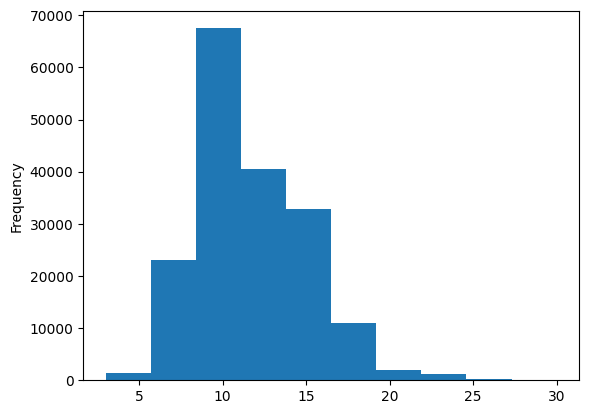

In [ ]:
train_df.total_lines.plot.hist()

In [ ]:
# Convert abstract text lines into lists
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
len(train_sentences), len(val_sentences), len(test_sentences)


(180040, 30212, 30135)

In [ ]:
#view first 10 lines of training sentences
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

#Make numeric labels(ML models require numeric labels)

To numerically encode labels we'll use scikit-Learn's OneHotEncoder and LabelEncoder classes

In [ ]:
# One hot encode labels
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1, 1))

# Check what training labels look like
train_labels_one_hot


array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

#Lable encode labels

In [ ]:
# Extract labels ("target" columns) and encode them into integers
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_labels_encoded = label_encoder.transform(test_df["target"].to_numpy())

# Check what training labels look like
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

Now we've trained an instance LabelEncoder , we can get the class names and number of classes using classes_attribute

In [ ]:
# Get class names and number of classes from LabelEncoder Instance
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes , class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

# Creating a series of model experiments

We've proprocessed our data so now, in true machine learning fashion, its time to setup a series of modelling experiments.

Starting by creating baseline model to obtain a score we'll try to beat by building more and more complex models as we move towards replicating the sequence model outlines in Neural Networks for joint sentence classification in medical paper abstracts.


For each model, we'll train it on the training data and evaluate it on validation data

# MODEL 0: Getting a baseline
Our first model we'll be TF-IDF Multinomial Naives Bayes

To build it, we'll create a scikit-Learn pipeline which uses the TfidVectorizer class to convert our abstract sentences using Tf-IDF(term frequency-inverse document frequency) algorithm and then learns to classify our sentences using MultinomialNB Alogorithm

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

#Create a pipeline

model_0 = Pipeline([
    ("tfidf", TfidfVectorizer()), # convert words to numbers using tfidf
    ("clf", MultinomialNB()) # model the text
])

# Fit the pipeline to the training data
model_0.fit(X= train_sentences, y= train_labels_encoded)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

Due to the speed of the multinomail Naive Bayes alogoruthm , it trains very quickly.
We can evaluate our model's accuracy on the validation dataset using the score() method.

In [ ]:
# Evaluate baseline on validation dataset
model_0.score(X= val_sentences,
                y = val_labels_encoded)

0.7218323844829869

we have got an accuracy of 72.1% , now we will develop more models for better accuracy than this

In [ ]:
# Now lets make some predictions with our baseline model to further evaluate it
# make predictions
baseline_preds = model_0.predict(val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1])

To evaluate our baseline's predictions , we'll import calculate_results() function, we will create a helper function
Helper function helps us get the following for a model:
* Accuracy
* Precision
* Recall
* F1- Score

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [ ]:
def calculate_results(y_true, y_pred):
  """
  Calculates model accuracy, precision, recall and f1 score of a binary classification model.

  Args:
      y_true: true labels in the form of a 1D array
      y_pred: predicted labels in the form of a 1D array

  Returns a dictionary of accuracy, precision, recall, f1-score.
  """
  # Calculate model accuracy
  model_accuracy = accuracy_score(y_true, y_pred) * 100
  # Calculate model precision, recall and f1 score using "weighted average
  model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
  model_results = {"accuracy": model_accuracy,
                  "precision": model_precision,
                  "recall": model_recall,
                  "f1": model_f1}
  return model_results

In [ ]:
baseline_results = calculate_results(y_true = val_labels_encoded,
                                     y_pred = baseline_preds)
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

### Preparing our data for deep sequence models

#Before we go on with deeper models we have to create vectorization and embedding layers.

The vectorization layer will covert our text to numbers and embedding layer will capture the relationships btw those numbers.

Importing appropiate libraies to do so(TensorFlow and Numpy)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

Since we'll be turning our sentences into numbers , its a good idea to figure out how many words are in each sentence.

When our model goes through our sentences , it works best when they'all are  the same length(this is  imp for creating batches for the same size tensors)

For example , if one sentence is 8 words long another is 29 words long , we want to pad the 8 word sentence with zeros so it ends up being the same length as 29 word sentence.


To make this process easier lets find avg length of sentences in trainig set.

In [ ]:
sent_lens =[len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len  # Return average sentence length (in tokens)

np.float64(26.338269273494777)

(array([1.5999e+05, 1.8760e+04, 1.1510e+03, 9.9000e+01, 2.8000e+01,
        1.0000e+01, 2.0000e+00]),
 array([  1.        ,  43.14285714,  85.28571429, 127.42857143,
        169.57142857, 211.71428571, 253.85714286, 296.        ]),
 <BarContainer object of 7 artists>)

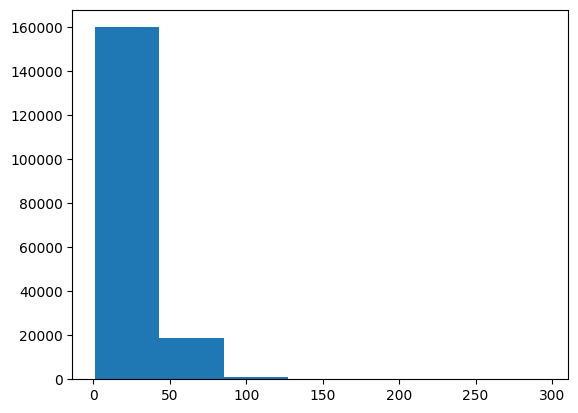

In [ ]:
# look at the distribution
import matplotlib.pyplot as plt
plt.hist(sent_lens , bins= 7)

Majority of the sentences are between 0 and 50 token in length.

Using Numpy's percentile we can find the value which covers 95% of the sentence lengths.

In [ ]:
# How long of a sentence covers 95% of the lengths ?
output_seq_len = int(np.percentile(sent_lens, 95))
output_seq_len

55

It looks like 95% of the sentences in our training set have a length of 55 token or less.

For tokenization layer, we'll use this value to turn all of our sentences into the same length. Meaning sentences with lengh below 55 will get padded with zeroes and sentences with a length over 55 will get truncated.

#Create text vectorizer
Using TextVectorization layer from TEnsorFlow.

max_tokens ( the number of unique words in our dataset)

output_sequence_length(our desired output for each vectorized sentence).

The vocab size of the PubMed 20k dataset is 68,000 , so will be using max_tokens parameter.

In [ ]:
max_tokens = 68000

In [ ]:
# Creating text vectorizer

from tensorflow.keras.layers import TextVectorization

text_vectorizer = TextVectorization(max_tokens = max_tokens, # number of words in vocab
                                    output_sequence_length = 55) #desired output length of vectorized sequences


In [ ]:
# Adapt text vectorizer to training sentences
text_vectorizer.adapt(train_sentences)

In [ ]:
import random
target_sentence = random.choice(train_sentences)
print(f"Text:\n{target_sentence}")
print(f"\Length of the text:{len(target_sentence.split())}")
print(f"\nVectorized text: \n{text_vectorizer([target_sentence])}")


<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_2203/2415900867.py:4: SyntaxWarning: invalid escape sequence '\L'
  print(f"\Length of the text:{len(target_sentence.split())}")


Text:
to observe the therapeutic effect of chishaodanpi decoction ( csdpd ) on chronic viral cholestatic hepatitis .
\Length of the text:17

Vectorized text: 
[[    6  1756     2   438    70     4 61612  5088 39928    18   244  1504
  20981  1363     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]]


In [ ]:
# How many words in our training vocabulary
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Number of words in the vocabulary: {len(rct_20k_text_vocab)}")
print(f"Most common words : {rct_20k_text_vocab[:5]}")
print(f"Least common words: {rct_20k_text_vocab[-5:]}")

Number of words in the vocabulary: 64841
Most common words : ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of')]
Least common words: [np.str_('aainduced'), np.str_('aaigroup'), np.str_('aachener'), np.str_('aachen'), np.str_('aaacp')]


In [ ]:
#Get the config of our text vectorizer
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

#Create custom text embedding
Create a trainable embedding layer using tensorflow's Embedding layer.

Main parameters of the Embedding layer are input_dim and the output_dim.

In [ ]:
#Create token embedding layer
token_embed = layers.Embedding(input_dim =len(rct_20k_text_vocab), #Length of the vocabulary
                               output_dim =128, # Different embedding sizes result in drastically different numbers of parameters to train
                               # use masking to handle variable sequence Lengths
                               mask_zero= True,
                               name ="token_embedding")

# show example embedding
print(f"Sentence before vectorization:\n {target_sentence}\n")
vectorized_sentence = text_vectorizer([target_sentence])
print(f"Sentence after vectorization(before embedding):\n{vectorized_sentence}\n")
embedded_sentence = token_embed(vectorized_sentence)
print(f"Sentence after embedding:\n{embedded_sentence}\n")
print(f"Embedded sentence shape: {embedded_sentence.shape}")

Sentence before vectorization:
 to observe the therapeutic effect of chishaodanpi decoction ( csdpd ) on chronic viral cholestatic hepatitis .

Sentence after vectorization(before embedding):
[[    6  1756     2   438    70     4 61612  5088 39928    18   244  1504
  20981  1363     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]]

Sentence after embedding:
[[[ 0.04690378  0.01637603 -0.02011015 ...  0.00318335 -0.04165745
    0.039336  ]
  [-0.00272876  0.00329833  0.0423146  ...  0.03502608 -0.02687188
   -0.03736874]
  [-0.00061844  0.04543919 -0.04912827 ... -0.04884711 -0.02892916
    0.0397781 ]
  ...
  [ 0.00173299  0.02059687  0.01544693 ...  0.04959187  0.01270839
   -0.01573244]
  [ 0.00173299  0.02059687  0.01544693 ...  0.04959187  0.01270839
   -0.01573244]
  [ 0.00173299  0.

#Create datasets
Turn our datasets into tensorflow datasets

In [ ]:
# Turn our data into Tensorflow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot))

train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(5,), dtype=tf.float64, name=None))>

In [ ]:
# Take the TensorSliceDataset's and turn them into prefetched batches
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

### MODEL 1: Conv1D with token embeddings

Deep models will follow a similar structure:

Input(text) -> Tokenize -> Embedding -> Layers -> Output (Label Probability)

The main component we'll be changing throughout is the layers component. Because any modern NLP model requires text to be converted into an embedding before meaningful patterns can be discovered within.

First , will build 1-Dimentional Convd Neural Network

Build -> Train-> Evaluate

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers


In [ ]:
# Create 1D convolutional model to process sequences
inputs = layers.Input(shape=(1,), dtype=tf.string)
text_vectors = text_vectorizer(inputs) # vectorize text inputs
token_embeddings = token_embed(text_vectors) # create embedding
x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(token_embeddings)
x = layers.GlobalAveragePooling1D()(x) # condense the output of our feature vector
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_1 = tf.keras.Model(inputs, outputs)

# Compile
model_1.compile(loss="categorical_crossentropy", # if your labels are integer form (not one hot) use sparse_categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [ ]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 55, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

Majority of the trainable parameters arew ithin the embedding layer. If we were to increase the size of the embedding (by increaing the output_dim parameter of the embedding layer), the number of trainable parameters would increase dramatically.

So, training data set contains 200k sentences , we will run them on a subset of the training dataset.

10% of training dataset we will use.



In [ ]:
#Fit the model
model_1_history = model_1.fit(train_dataset,
                              steps_per_epoch =int(0.1 * len(train_dataset)), #only fit on 10% of batches for faster training time
                              epochs =3 ,
                              validation_data = valid_dataset,
                              validation_steps = int(0.1 * len(valid_dataset))) #only validate on 10% of batches

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6414 - loss: 0.9147 - val_accuracy: 0.7443 - val_loss: 0.6835
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7595 - loss: 0.6535 - val_accuracy: 0.7713 - val_loss: 0.6358
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7767 - loss: 0.6129 - val_accuracy: 0.7842 - val_loss: 0.5969


In [ ]:
# Make predictions
model_1_pred_probs = model_1.predict(valid_dataset)
model_1_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[4.49690431e-01, 1.38950914e-01, 7.15169013e-02, 3.16968530e-01,
        2.28731763e-02],
       [4.00707543e-01, 3.41143101e-01, 1.21475970e-02, 2.33228564e-01,
        1.27732232e-02],
       [1.24029964e-01, 3.37341311e-03, 1.69092638e-03, 8.70878100e-01,
        2.74845788e-05],
       ...,
       [9.02104603e-06, 9.30750335e-04, 9.69916757e-04, 1.26173327e-05,
        9.98077631e-01],
       [3.39917094e-02, 4.57490057e-01, 8.05017427e-02, 4.37814184e-02,
        3.84235114e-01],
       [1.58978522e-01, 7.44330585e-01, 4.84942645e-02, 2.60920301e-02,
        2.21046209e-02]], dtype=float32)

In [ ]:
# Convert pred probs to classes
model_1_preds = tf.argmax(model_1_pred_probs, axis =1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1])>

In [ ]:
# Calculate model_1 results
model_1_results = calculate_results(y_true = val_labels_encoded,
                                    y_pred = model_1_preds)
model_1_results

{'accuracy': 78.74685555408448,
 'precision': 0.7842198192184274,
 'recall': 0.7874685555408447,
 'f1': 0.7849424169228847}

###MODEL 2: Feature extraction with pretrained token embeddings

In the dataset they have used pretrained GloVe embedding as a way to initialisse their embeddings.

To emulate this , lets see what results we can get with pretrained Universal sentence Encoder embeddings from TensorFlow Hub. (GloVe emebeddings arent presnet in  TensorFlow hub)

The modek structure will look like:
Inputs(string) -> Pretrained embeddings from TensorFlow Hub( Universal sentence Encoder) -> Layers -> Output(prediction probabilities)

This  type of model is called  transfer learning or more specifically, *Feature extraction transfer learning*. In other words , taking the patterns a model has learned elsewhere and applying it ti our own problem.

The feature extractor model we're building using a pretrained embedding model from TensorFlow Hub.

### Building and Fitting an NLP feature extraction model from TensorFlow Hub

Checking the summary of our model we can see there's a large number of total parameters , however , the majority of these non-trainable. This is because we set trainning =False when we initiated our USE feature extractor layer.

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, Model

# Custom wrapper for USE
class USELayer(layers.Layer):
    def __init__(self, hub_url, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.hub_url = hub_url
        self.trainable = trainable
        self._embed = None

    def build(self, input_shape):
        # Load the TF Hub model once
        self._embed = hub.load(self.hub_url)
        super().build(input_shape)

    def call(self, inputs):
        # Ensure proper shape: (batch,) strings
        inputs = tf.reshape(inputs, [-1])
        return self._embed(inputs)

# Instantiate the embedding layer
tf_hub_embedding_layer = USELayer("https://tfhub.dev/google/universal-sentence-encoder/4")

# Build your model
inputs = layers.Input(shape=(), dtype=tf.string, name="text_input")
pretrained_embedding = tf_hub_embedding_layer(inputs)
x = layers.Dense(128, activation="relu")(pretrained_embedding)
outputs = layers.Dense(5, activation="softmax")(x)

model_2 = Model(inputs=inputs, outputs=outputs)

# Compile
model_2.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
    jit_compile =False # This stops XLA JIT for the model
)

model_2.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ use_layer (USELayer)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,309 (259.02 KB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Fit feature extractor model for 3 epochs
model_2.fit(train_dataset,
            steps_per_epoch = int(0.1* len(train_dataset)),
            epochs= 3,
            validation_data = valid_dataset,
            validation_steps = int(0.1* len(valid_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6500 - loss: 0.9135 - val_accuracy: 0.6888 - val_loss: 0.7964
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7034 - loss: 0.7685 - val_accuracy: 0.7038 - val_loss: 0.7549
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7118 - loss: 0.7518 - val_accuracy: 0.7151 - val_loss: 0.7365


In [ ]:
# Evaluate on whole validation dataset
model_2.evaluate(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7158 - loss: 0.7396


[0.7395917773246765, 0.7158414125442505]

In [ ]:
# make predictions with feature extraction model
model_2_pred_probs = model_2.predict(valid_dataset)
model_2_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


array([[4.3371651e-01, 3.6142254e-01, 3.3662843e-03, 1.9194165e-01,
        9.5530897e-03],
       [3.6358038e-01, 5.0402260e-01, 5.1468965e-03, 1.2342581e-01,
        3.8243800e-03],
       [2.2450615e-01, 1.3972420e-01, 2.2966662e-02, 5.7612568e-01,
        3.6677364e-02],
       ...,
       [1.6723706e-03, 7.5411755e-03, 5.8835618e-02, 7.9234038e-04,
        9.3115854e-01],
       [3.2743197e-03, 4.2118512e-02, 1.7774330e-01, 1.0218733e-03,
        7.7584195e-01],
       [1.5883544e-01, 2.5987002e-01, 5.2410430e-01, 5.8681397e-03,
        5.1322110e-02]], dtype=float32)

In [ ]:
#convert the predictions withh feature extraction mode to classes
model_2_preds = tf.argmax(model_2_pred_probs , axis =1)
model_2_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 3, ..., 4, 4, 2])>

In [ ]:
#calculate results from TF Hub pretrained embeddings results on validation set
model_2_results = calculate_results(y_true = val_labels_encoded,
                                    y_pred = model_2_preds)
model_2_results

{'accuracy': 71.58413875281346,
 'precision': 0.716368496710221,
 'recall': 0.7158413875281345,
 'f1': 0.712940233972697}

# MODEL 3: Conv1D with character embeddings

Creating a character-level tokenizer
 The difference between a character and token embedding is that , in character embedding each letter is converted into feature vector but in token embedding , each word is converted into feature vector.

 Character-level embedding is done by first vectorizing our sequences(after they have been split into characters) using the TextVectorization class and then passing those vectorized sequences through an Embedding layer.

In [ ]:
#Make functions to split sentences into characters
def split_chars(text):
  return " ".join(list(text))

# Test splitting non-character-level sequence into characters
split_chars(random.choice(train_sentences))

'o s   w a s   u s e d   f o r   p r i m a r y   e n d p o i n t   a n d   p r o g r e s s i o n - f r e e   s u r v i v a l   (   p f s   )   w a s   u s e d   f o r   s e c o n d a r y   e n d p o i n t   .'

In [ ]:
#split sequence-level data split into character-level data splits

train_chars =[split_chars(sentence) for sentence in train_sentences]
val_chars = [split_chars(sentence) for sentence in val_sentences]
test_chars= [split_chars(sentence) for sentence in test_sentences]
print(train_chars[0])

t o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .


Figuring out how long our vectorized sequences should be , lets check the distribution of our character sequence lengths.

In [ ]:
#What's the average character length?
char_lens = [len(sentence) for sentence in train_sentences]
mean_char_len = np.mean(char_lens)
mean_char_len

np.float64(149.3662574983337)

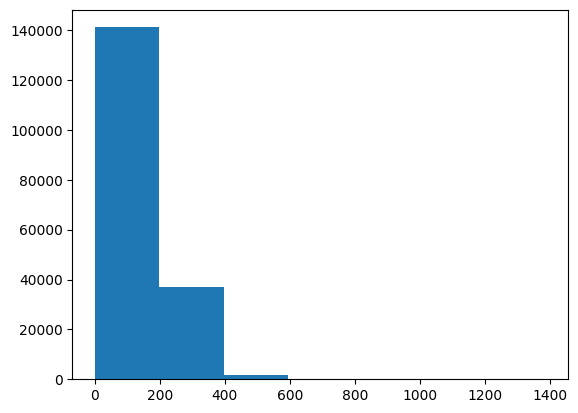

In [ ]:
# check the distribution of our sequences of character -level
import matplotlib.pyplot as plt
plt.hist(char_lens, bins =7);

Most of our sequences are between 0 and 200 characters long.

Again using NumPy's percentile to figure out what length 95% of our sequences.

In [ ]:
output_seq_char_len = int(np.percentile(char_lens, 95))
output_seq_char_len

290

Max tokens will set to 28 , 26 letters of alphabet + space + OOV( out of vocabulary or unknown) tokens.

In [ ]:
import string
alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# Create char-level token vectorizer instance
NUM_CHAR_TOKENS = len(alphabet) + 2 # num characters in alphabet + space + OOV token
char_vectorizer = TextVectorization(max_tokens=NUM_CHAR_TOKENS,
                                    output_sequence_length=output_seq_char_len,
                                    standardize="lower_and_strip_punctuation",
                                    name="char_vectorizer")
# Adapt character vectorizer to training characters
char_vectorizer.adapt(train_chars)

In [ ]:
# Check character vocabulary characteristics
char_vocab = char_vectorizer.get_vocabulary()
print(f"Number of characters in the vocabulary: {len(char_vocab)}")
print(f" 5 most common characters: {char_vocab[:5]}")
print(f"5 Least common characters: {char_vocab[-5:]}")

Number of characters in the vocabulary: 28
 5 most common characters: ['', '[UNK]', np.str_('e'), np.str_('t'), np.str_('i')]
5 Least common characters: [np.str_('k'), np.str_('x'), np.str_('z'), np.str_('q'), np.str_('j')]


# Testiing on random sentence from the dataset

In [ ]:
random_train_chars = random.choice(train_chars)
print(f"charified text:\n{random_train_chars}")
print(f"\n Length of chars: {len(random_train_chars.split())}")
vectorized_chars = char_vectorizer([random_train_chars])
print(f"\nVectorized text: \n{vectorized_chars}")
print(f"\nLength of vectorized chars: {len(vectorized_chars[0])}")

charified text:
a m o n g   l a r g e r   g r o u p s   ,   b e t t e r   q u a l i t y   f o r   w h i t e   b e n e f i c i a r i e s   i n   o n e   m e a s u r e   (   h o s p i t a l i z a t i o n   f o r   a c s c s   r e l a t e d   t o   c a r d i o v a s c u l a r   d i s e a s e   o r   d i a b e t e s   )   w a s   c o r r e l a t e d   w i t h   s m a l l e r   r a c i a l   d i s p a r i t i e s   (   r   =   @   ;   p   =   @   )   ,   b u t   q u a l i t y   w a s   n o t   c o r r e l a t e d   w i t h   d i s p a r i t i e s   i n   o t h e r   m e a s u r e s   .

 Length of chars: 237

Vectorized text: 
[[ 5 15  7  6 18 12  5  8 18  2  8 18  8  7 16 14  9 22  2  3  3  2  8 26
  16  5 12  4  3 19 17  7  8 20 13  4  3  2 22  2  6  2 17  4 11  4  5  8
   4  2  9  4  6  7  6  2 15  2  5  9 16  8  2 13  7  9 14  4  3  5 12  4
  25  5  3  4  7  6 17  7  8  5 11  9 11  9  8  2 12  5  3  2 10  3  7 11
   5  8 10  4  7 21  5  9 11 16 12  5  8 10  4  9  2  5  9  2  7  8 10  4


When the length is shorter than 290 , it is padded with zeroes.

Character-level embedding layer requires an input dimension and output dimension.

The parameters:
* The input_dim will be equal to the number of different characters in our char_vocab(28)
* The output_dim of the emebedding will be 25

In [ ]:
# Create char embedding layer
char_embed = layers.Embedding(input_dim=NUM_CHAR_TOKENS, # number of different characters
                              output_dim=25, # embedding dimension of each character (same as Figure 1 in https://arxiv.org/pdf/1612.05251.pdf)
                              mask_zero=False, # don't use masks (this messes up model_5 if set to True)
                              name="char_embed")

# Test out character embedding layer
print(f"Charified text (before vectorization and embedding):\n{random_train_chars}\n")
char_embed_example = char_embed(char_vectorizer([random_train_chars]))
print(f"Embedded chars (after vectorization and embedding):\n{char_embed_example}\n")
print(f"Character embedding shape: {char_embed_example.shape}")


Charified text (before vectorization and embedding):
a m o n g   l a r g e r   g r o u p s   ,   b e t t e r   q u a l i t y   f o r   w h i t e   b e n e f i c i a r i e s   i n   o n e   m e a s u r e   (   h o s p i t a l i z a t i o n   f o r   a c s c s   r e l a t e d   t o   c a r d i o v a s c u l a r   d i s e a s e   o r   d i a b e t e s   )   w a s   c o r r e l a t e d   w i t h   s m a l l e r   r a c i a l   d i s p a r i t i e s   (   r   =   @   ;   p   =   @   )   ,   b u t   q u a l i t y   w a s   n o t   c o r r e l a t e d   w i t h   d i s p a r i t i e s   i n   o t h e r   m e a s u r e s   .

Embedded chars (after vectorization and embedding):
[[[ 2.6806299e-02 -2.2685898e-02  1.4755916e-02 ...  4.1727591e-02
   -1.1086535e-02  2.8584968e-02]
  [ 1.6557965e-02  1.1866868e-02  4.6782199e-02 ...  1.7268542e-02
   -3.6777485e-02  3.0362222e-02]
  [ 1.9580591e-02 -2.2512246e-02  4.0420119e-02 ...  2.4291720e-02
   -3.6316313e-02  4.4849429e-02]
  ...
  [ 8.0227852

#Building a Conv1D model to fit on character embeddings

Turn our character-level sequences into numbers(char_vectorizer) as well as numerically represnt them as an embedding (char_embed)

Input(character-level text) -> Tokenize-> Embedding -> Layers( Conv1D , GlobalMaxPool1D) -> Output(label probability)

In [ ]:
# Make Conv1D on chars only
inputs = layers.Input(shape=(1,), dtype="string")
char_vectors = char_vectorizer(inputs)
char_embeddings = char_embed(char_vectors)
x = layers.Conv1D(64, kernel_size = 5, padding ="same", activation="relu")(char_embeddings)
x = layers.GlobalMaxPool1D()(x)
outputs = layers.Dense(num_classes , activation ="softmax")(x)
model_3 = tf.keras.Model(inputs = inputs,
                         outputs =outputs,
                         name = "model_3_char_embedding")
# Compile the model
model_3.compile(loss = "categorical_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
model_3.summary()

Model: "model_3_char_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_vectorizer                 │ (None, 290)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embed (Embedding)          │ (None, 290, 25)        │         1,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 290, 64)        │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,139 (39.61 KB)

 Trainable params: 10,139 (39.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#create char datasets
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_chars, train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset = tf.data.Dataset.from_tensor_slices((val_chars, val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

train_char_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

In [ ]:
#Fitting the model
model_3_history = model_3.fit(train_char_dataset,
                              steps_per_epoch =int(0.1* len(train_char_dataset)),
                              epochs = 3 ,
                              validation_data = val_char_dataset,
                              validation_steps = int(0.1* len(val_char_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4982 - loss: 1.2381 - val_accuracy: 0.5868 - val_loss: 1.0381
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5924 - loss: 1.0093 - val_accuracy: 0.6297 - val_loss: 0.9461
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6345 - loss: 0.9270 - val_accuracy: 0.6592 - val_loss: 0.8751


In [ ]:
# Evaluate the model
model_3_pred_probs = model_3.predict(val_char_dataset)
model_3_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


array([[0.13400821, 0.5132908 , 0.06397849, 0.2395061 , 0.04921639],
       [0.21457206, 0.31670946, 0.04550668, 0.25220987, 0.17100193],
       [0.1431232 , 0.37795427, 0.13942802, 0.28840646, 0.05108809],
       ...,
       [0.00828179, 0.03035142, 0.20774001, 0.01585961, 0.7377672 ],
       [0.03884104, 0.09465363, 0.39733556, 0.01949164, 0.44967812],
       [0.3290554 , 0.45065802, 0.07949811, 0.11784571, 0.02294273]],
      dtype=float32)

In [ ]:
# Convert the predictions to classes
model_3_preds = tf.argmax(model_3_pred_probs, axis =1 )
model_3_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([1, 1, 1, ..., 4, 4, 1])>

In [ ]:
# Calculate the results of Conv1D char only model
model_3_results = calculate_results(y_true = val_labels_encoded,
                                    y_pred = model_3_preds)
model_3_results

{'accuracy': 65.288627035615,
 'precision': 0.6460716714742428,
 'recall': 0.6528862703561499,
 'f1': 0.6459761804031121}

## MODEL 4: Combining pretrained token embeddings + character embeddings(hybrid embedding layer)

This hybrid embedding layer is a combination of token embeddings and character emebddings. In other words, they create a stacked embedding to represent sequences before passing them to the sequence label prediction layer.

1. Create a token-level model(similar to model_1)

2. Create a character-level model(similar to model_3 with a slight modification to reflect the paper)

3. combine (using layers.Concatenate) the outputs of 1 and 2.

4. Build a series of output layers on top f 3 similar.

5. Construct a model which takes token and character-level sequences as input and produces sequence label probabilities as output

In [ ]:
#1. setup token inputs/model
token_inputs = layers.Input(shape=[] , dtype = tf.string , name ="token_input")
token_embeddings = tf_hub_embedding_layer(token_inputs)
token_output = layers.Dense(128, activation ="relu")(token_embeddings)
token_model = tf.keras.Model(inputs = token_inputs,
                             outputs = token_output)

# 2. Setup char inputs/model
char_inputs = layers.Input(shape=(1,) , dtype =tf.string , name ="char_input")
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(25))(char_embeddings)
char_model = tf.keras.Model(inputs = char_inputs,
                            outputs = char_bi_lstm)

#3. Concatenate token and char inputs(create hybrid token embedding)
token_char_concat = layers.Concatenate(name = "token_char_hybrid")([token_model.output,
                                                                    char_model.output])

#4. create output layers
combined_dropout = layers.Dropout(0.5)(token_char_concat)
combined_dense = layers.Dense(200, activation ="relu")(combined_dropout)
final_dropout = layers.Dropout(0.5)(combined_dense)
output_layer = layers.Dense(num_classes , activation= "softmax" )(final_dropout)

# 5. Construct model with char and token inputs
model_4 = tf.keras.Model(inputs =[token_model.input , char_model.input],
                         outputs = output_layer,
                         name = "model_4_token_char_embeddings")




In [ ]:
# Get summary
model_4.summary()

Model: "model_4_token_char_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_input         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_layer           │ (None, 512)       │          0 │ token_input[0][0] │
│ (USELayer)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │      1,750 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     65,664 │ use_layer[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50)        │     10,200 │ char_embed[1][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid   │ (None, 178)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 178)       │          0 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 200)       │     35,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 200)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 5)         │      1,005 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,419 (446.95 KB)

 Trainable params: 114,419 (446.95 KB)

 Non-trainable params: 0 (0.00 B)

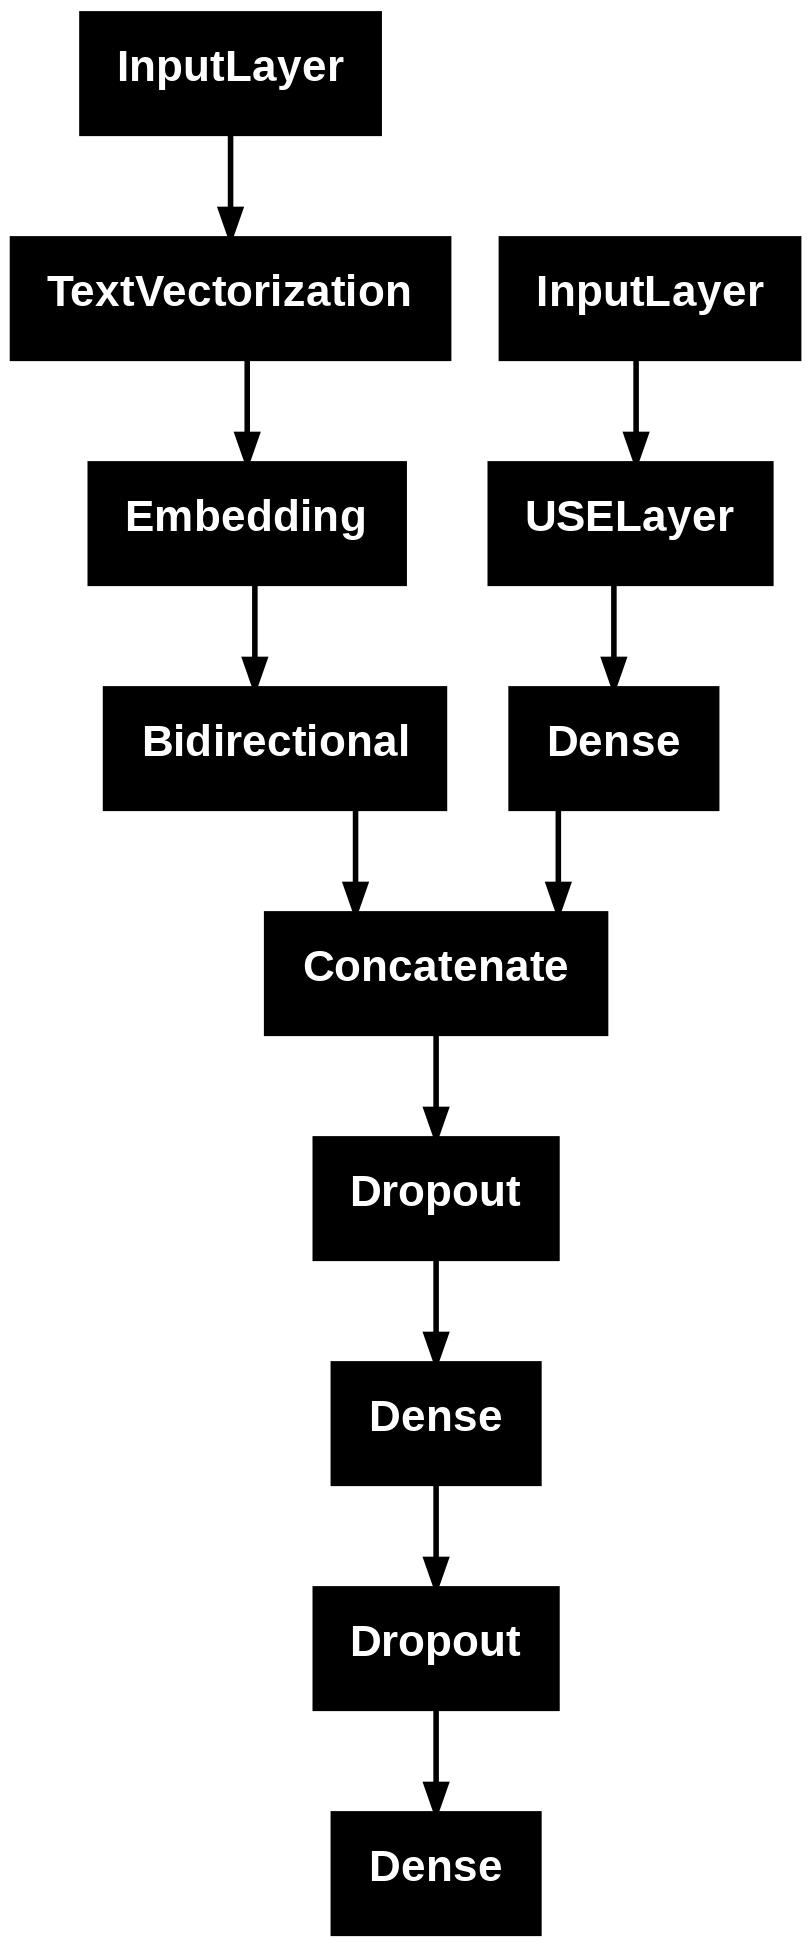

In [ ]:
#Plot hybrid token and character model
from tensorflow.keras.utils import plot_model
plot_model(model_4)


In [ ]:
#Compile token char model
model_4.compile(loss = "categorical_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics =["accuracy"])

This model requires two inputs, token-level sequences and character-level sequences.

Creat a tf.data.Dataset with a tuple as it's first input, for example:
* ( ( token_data , char_data) , (label) )

### Combining token and character data into tf.data dataset

In [ ]:
#Combine chars and tokens into a dataset
train_char_token_data = tf.data.Dataset.from_tensor_slices((train_sentences , train_chars))  #make data
train_char_token_labels = tf.data.Dataset.from_tensor_slices((train_labels_one_hot)) #make labels
train_char_token_dataset = tf.data.Dataset.zip((train_char_token_data , train_char_token_labels))  #combine data and labels

#prefetch and batch train data
train_char_token_dataset = train_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

#Repeat same steps validation data
val_char_token_data = tf.data.Dataset.from_tensor_slices((val_sentences , val_chars))
val_char_token_labels = tf.data.Dataset.from_tensor_slices(val_labels_one_hot)
val_char_token_dataset = tf.data.Dataset.zip((val_char_token_data , val_char_token_labels))
val_char_token_dataset = val_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Check out training char and token embedding dataset
train_char_token_dataset , val_char_token_dataset

(<_PrefetchDataset element_spec=((TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=((TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>)

In [ ]:
#FIt the model on tokens and chars
model_4_history = model_4.fit(train_char_token_dataset,
                              steps_per_epoch = int(0.1* len(train_char_token_dataset)),
                              epochs = 3,
                              validation_data = val_char_token_dataset,
                              validation_steps = int(0.1* len(val_char_token_dataset)))


Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6171 - loss: 0.9661 - val_accuracy: 0.7001 - val_loss: 0.7777
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.6957 - loss: 0.7937 - val_accuracy: 0.7307 - val_loss: 0.7147
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.7040 - loss: 0.7692 - val_accuracy: 0.7374 - val_loss: 0.6911


In [ ]:
# Evaluate
model_4.evaluate(val_char_token_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.7349 - loss: 0.6956


[0.6956027746200562, 0.7349066734313965]

In [ ]:
# Make predictions using the token-character model hybrid:
model_4_pred_probs = model_4.predict(val_char_token_dataset)
model_4_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step


array([[4.03013915e-01, 3.80717784e-01, 3.24224913e-03, 2.05404252e-01,
        7.62185128e-03],
       [3.39542598e-01, 4.61391956e-01, 3.11675202e-03, 1.93332881e-01,
        2.61575240e-03],
       [3.11751276e-01, 1.04266874e-01, 4.11829054e-02, 5.09606719e-01,
        3.31921913e-02],
       ...,
       [4.44537407e-04, 5.42233372e-03, 3.60898487e-02, 2.18953515e-04,
        9.57824290e-01],
       [7.65567413e-03, 4.58793864e-02, 2.30221346e-01, 2.75484845e-03,
        7.13488698e-01],
       [2.20691696e-01, 3.45358849e-01, 3.53647649e-01, 1.91686489e-02,
        6.11331984e-02]], dtype=float32)

In [ ]:
#Turn predictions probabilities into prediction classes
model_4_preds = tf.argmax(model_4_pred_probs , axis =1)
model_4_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 3, ..., 4, 4, 2])>

In [ ]:
# Get results of token-char-hybrid model
model_4_results = calculate_results(y_true = val_labels_encoded,
                                    y_pred = model_4_preds)

model_4_results

{'accuracy': 73.49066596054547,
 'precision': 0.736536768881454,
 'recall': 0.7349066596054548,
 'f1': 0.7332402800830994}

###MODEL 5: Transfer learning with pretrained token embeddings + character embeddings + positional embeddings

Feature engineering.

Abstracts typically come in a sequential order, such as:
* OBEJECTIVE
* METHODS
* METHODS
* RESULTS
* CONCLUSIONS

OR

* BACKGROUND
* OBJECTIVE
* METHODS
* METHODS
* RESULTS
* RESULTS
* CONCLUSIONS
* CONCLUSIONS

we created our preprocess_text_with_line_numbers() function. When we read in a textfile of abstracts , we counted the number of lines in an abstract as well as the number of each line itself.



In [ ]:
train_df.head()

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


If we were to predict the labels of sequences in an abstract our model had never seen , we could count the number of lines and tract the position of each individual line and pass it to our model.

In [ ]:
#How many different line numbers are there
train_df["line_number"].value_counts()

,count
line_number,
0,15000
1,15000
2,15000
3,15000
4,14992
5,14949
6,14758
7,14279
8,13346


The above printed the the number of lines and its frequency.

<Axes: ylabel='Frequency'>

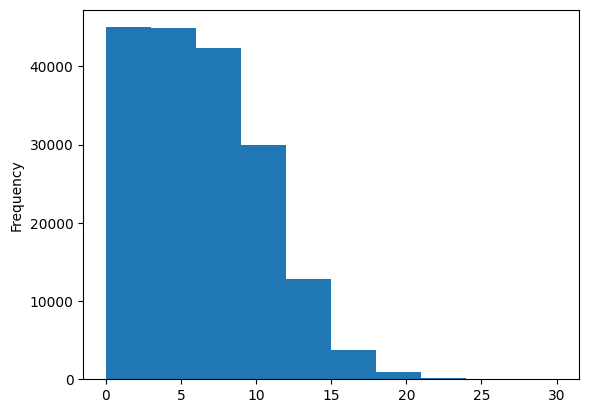

In [ ]:
# Check the distribution of "line_number" column
train_df.line_number.plot.hist()

looking at the distribution of the "line_number" column, it looks like the majority of lines have a position of 15 or less.

Setting the depth parameter of tf.one_hot to 15 means any sample with a "line_number" value of over 15 gets set to a tensor of all 0's , where as any sample with a "line_number" under 15 gets turned into a tensor of all 0's but with a 1 at the index equal to "line_number" value.

In [ ]:
# Useing tensorflow to create one-hot-encoded tensors of our "line_number" column
train_line_numbers_one_hot = tf.one_hot(train_df["line_number"].to_numpy(), depth = 15)
val_line_numbers_one_hot = tf.one_hot(val_df["line_number"].to_numpy(), depth =15)
test_line_numbers_one_hot = tf.one_hot(test_df["line_number"].to_numpy(), depth =15)

In [ ]:
#Checking one-hot encoded "line_number" feature samples
train_line_numbers_one_hot.shape , train_line_numbers_one_hot[:20]

(TensorShape([180040, 15]),
 <tf.Tensor: shape=(20, 15), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0.

In [ ]:
# How many different numbers of lines are there
train_df["total_lines"].value_counts()

,count
total_lines,
11,24468
10,23639
12,22113
9,19400
13,18438
14,14610
8,12285
15,10768
7,7464


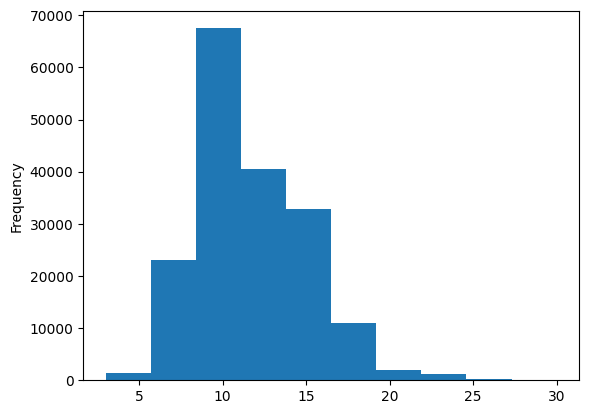

In [ ]:
# Checking the distribution of total lines
train_df.total_lines.plot.hist();

In [ ]:
# Checking the coverage of a "total_lines" value of 20
np.percentile(train_df.total_lines , 98)

np.float64(20.0)

In [ ]:
train_total_lines_one_hot = tf.one_hot(train_df["total_lines"].to_numpy() , depth =20)
val_total_lines_one_hot = tf.one_hot(val_df["total_lines"].to_numpy(), depth = 20)
test_total_lines_one_hot = tf.one_hot(test_df["total_lines"].to_numpy(), depth = 20)

In [ ]:
#Check shape and samples of one-hot tensor
train_total_lines_one_hot.shape , train_total_lines_one_hot[:10]

(TensorShape([180040, 20]),
 <tf.Tensor: shape=(10, 20), dtype=float32, numpy=
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0

Building a tribid embedding model
 This model incoporates token embeddings , character embedding and our newly crafted positional embeddings.


In [ ]:
# token inputs
token_inputs = layers.Input(shape =[], dtype ="string" , name = "token_inputs")
token_embeddings = tf_hub_embedding_layer(token_inputs)
token_outputs = layers.Dense(128 , activation ="relu")(token_embeddings)
token_model = tf.keras.Model(inputs = token_inputs,
                             outputs = token_outputs)

# Char inputs
char_inputs = layers.Input(shape=(1,) , dtype ="string" , name ="char_inputs")
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm =layers.Bidirectional(layers.LSTM(32))(char_embeddings)
char_model = tf.keras.Model(inputs = char_inputs,
                            outputs = char_bi_lstm)

# Line numbers inputs
line_number_inputs = layers.Input(shape=(15,), dtype=tf.int32, name="line_number_input")
x = layers.Dense(32, activation="relu")(line_number_inputs)
line_number_model = tf.keras.Model(inputs=line_number_inputs,
                                   outputs=x)

# Total lines inputs
total_lines_inputs = layers.Input(shape =(20,), dtype = tf.int32 , name ="total_lines_input")
y = layers.Dense(32 , activation ="relu")(total_lines_inputs)
total_lines_model = tf.keras.Model(inputs = total_lines_inputs,
                                   outputs = y)

# combine token and char embedding into a hybrid embedding
combined_embeddings = layers.Concatenate(name="token_char_hybrid_embedding")([token_model.output,
                                                                              char_model.output])
z = layers.Dense(256, activation="relu")(combined_embeddings)
z = layers.Dropout(0.5)(z)

# Combine positional embeddings with combined token and char embeddings into a tribrid embedding
z = layers.Concatenate(name ="token_char_positional_embedding")([line_number_model.output,
                                                                 total_lines_model.output,
                                                                 z])
# Create output layer
output_layer = layers.Dense(5, activation = "softmax" , name = "output_layer")(z)

# Put together model
model_5 = tf.keras.Model(inputs=[line_number_model.input,
                                 total_lines_model.input,
                                 token_model.input,
                                 char_model.input],
                         outputs=output_layer)


In [ ]:
model_5.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_inputs         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_inputs        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_inputs[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_layer           │ (None, 512)       │          0 │ token_inputs[0][… │
│ (USELayer)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │      1,750 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     65,664 │ use_layer[2][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     14,848 │ char_embed[2][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid_… │ (None, 192)       │          0 │ dense_7[0][0],    │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ line_number_input   │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ total_lines_input   │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │     49,408 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │        512 │ line_number_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │        672 │ total_lines_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_positio… │ (None, 320)       │          0 │ dense_8[0][0],    │
│ (Concatenate)       │                   │            │ dense_9[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 5)         │      1,605 │ token_char_posit… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 134,459 (525.23 KB)

 Trainable params: 134,459 (525.23 KB)

 Non-trainable params: 0 (0.00 B)

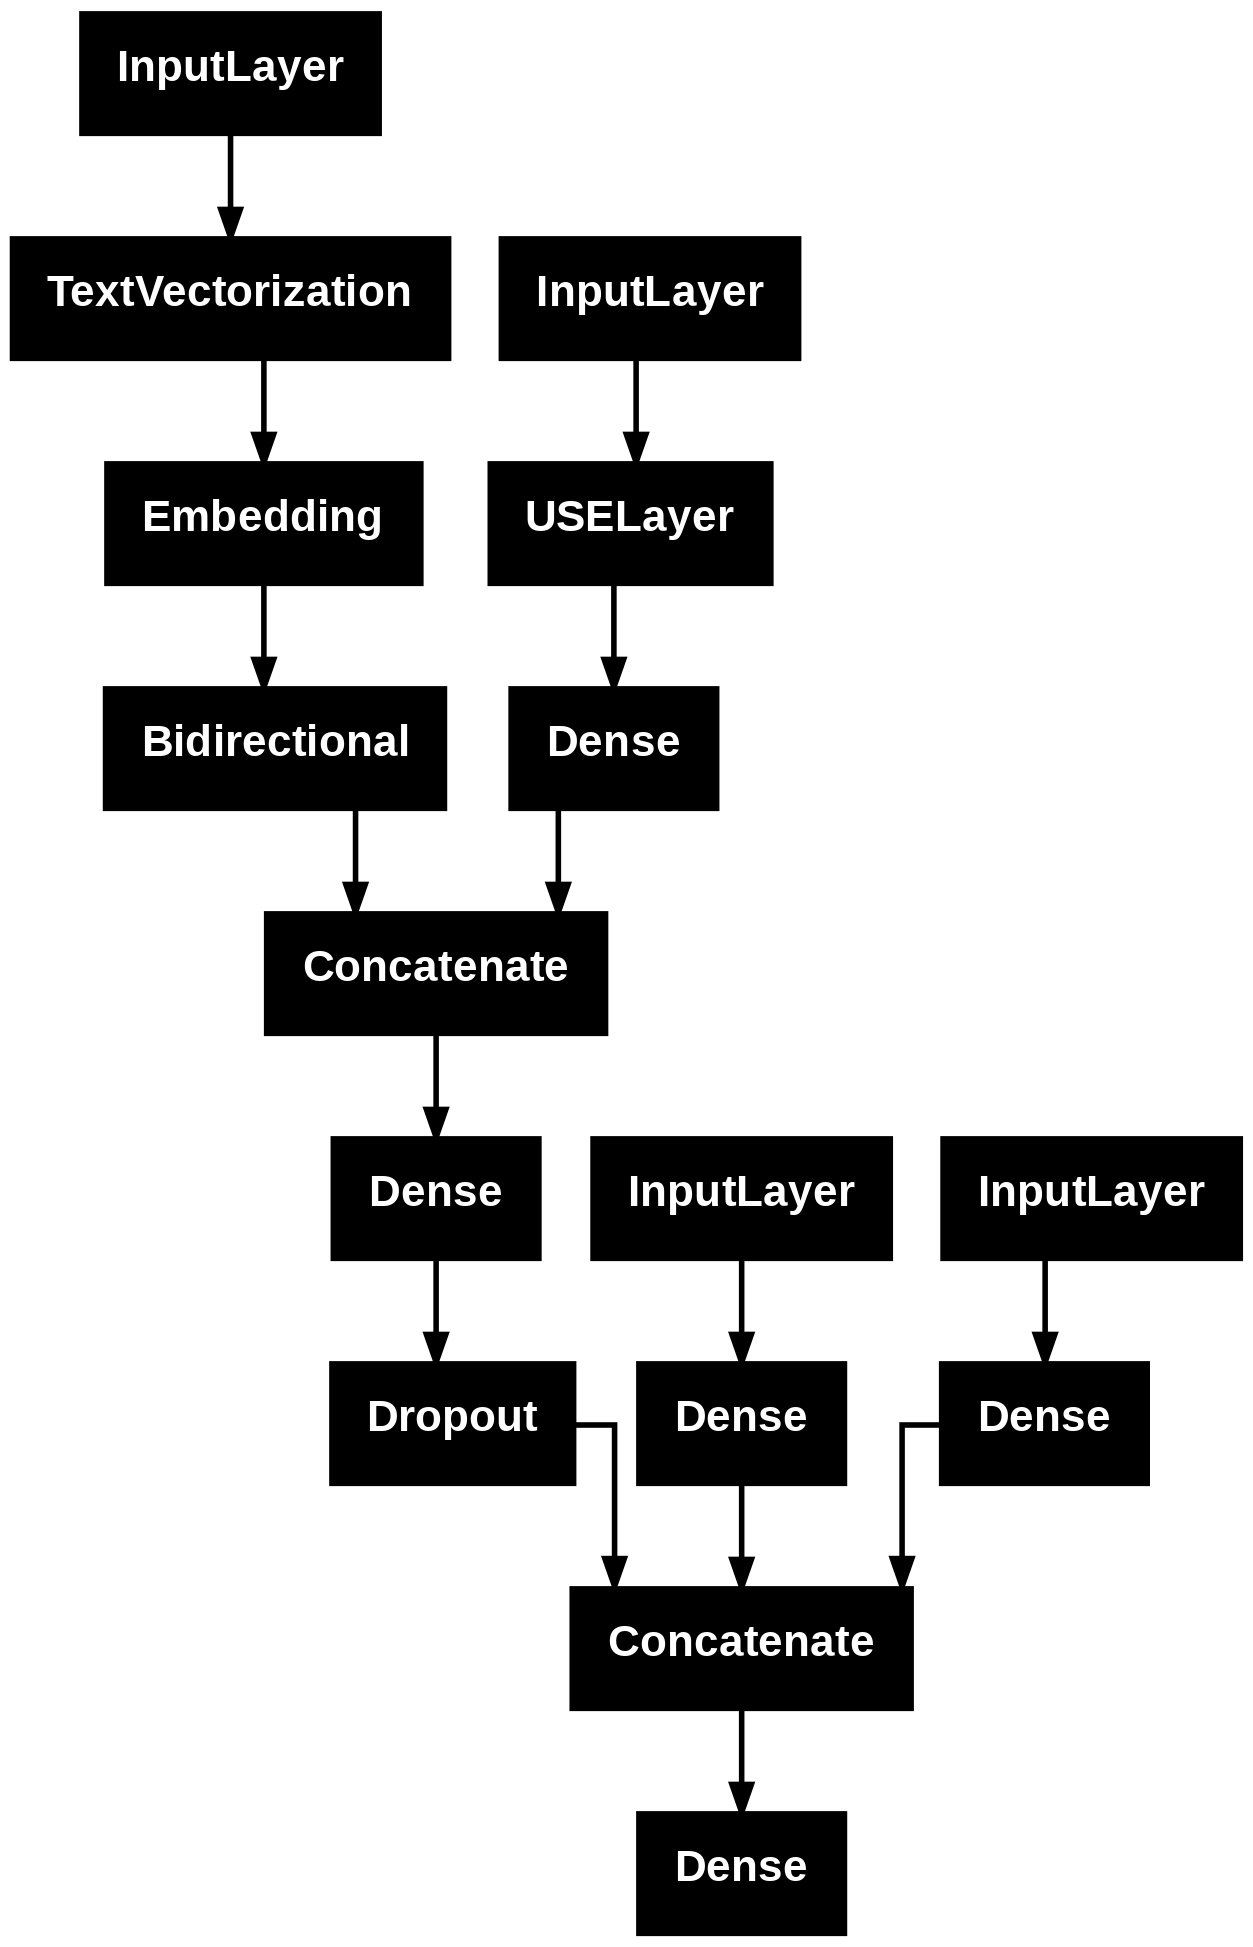

In [ ]:
#plot the tokem , char , positional embedding model
from tensorflow.keras.utils import plot_model
plot_model(model_5)

In [ ]:
#Check which layers of model 5 are trainable or not
for layer in model_5.layers:
  print(layer, layer.trainable)

<InputLayer name=char_inputs, built=True> True
<InputLayer name=token_inputs, built=True> True
<TextVectorization name=char_vectorizer, built=True> True
<USELayer name=use_layer, built=True> False
<Embedding name=char_embed, built=True> True
<Dense name=dense_7, built=True> True
<Bidirectional name=bidirectional_1, built=True> True
<Concatenate name=token_char_hybrid_embedding, built=True> True
<InputLayer name=line_number_input, built=True> True
<InputLayer name=total_lines_input, built=True> True
<Dense name=dense_10, built=True> True
<Dense name=dense_8, built=True> True
<Dense name=dense_9, built=True> True
<Dropout name=dropout_2, built=True> True
<Concatenate name=token_char_positional_embedding, built=True> True
<Dense name=output_layer, built=True> True


We will use label_smoothing , Label smoothing helps to regularize our model(prevent overfitting ) by making sure it doesnt get too focused on applying one particular label to a sample.


In [ ]:
# Compiling the model
model_5.compile(loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing = 0.2),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

#Create Tribid embedding datasets and fit tribid model

Will only do it for 10% of the data.

our model requires four feature inputs:

1. Train line numbers one-hot tensor (train_line_numbers_one_hot)
2. Train total lines one-hot tensor (train_total_lines_one_hot)
3. Token-level sequences tensor (train_sentences)
4. Char-level sequences tensor (train_chars)

willmpass these tuples to our tf.data.Dataset.from_tensor_slices() method to create appropriately shaped and batched prefetchedDataset's.

In [ ]:
train_pos_char_token_data = tf.data.Dataset.from_tensor_slices(( train_line_numbers_one_hot ,  # line numbers
                                                                 train_total_lines_one_hot , #total lines
                                                                 train_sentences,  # train tokens
                                                                 train_chars))  #train chars
train_pos_char_token_labels = tf.data.Dataset.from_tensor_slices(train_labels_one_hot) #train labels
train_pos_char_token_dataset = tf.data.Dataset.zip((train_pos_char_token_data , train_pos_char_token_labels)) #Combine data aand labels
train_pos_char_token_dataset = train_pos_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE) #turn into batches and prefetch appropriately

# Validation dataset
val_pos_char_token_data = tf.data.Dataset.from_tensor_slices((val_line_numbers_one_hot,
                                                              val_total_lines_one_hot,
                                                              val_sentences,
                                                              val_chars))
val_pos_char_token_labels = tf.data.Dataset.from_tensor_slices(val_labels_one_hot)
val_pos_char_token_dataset = tf.data.Dataset.zip((val_pos_char_token_data , val_pos_char_token_labels))
val_pos_char_token_dataset = val_pos_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

#Check input shapes
train_pos_char_token_dataset , val_pos_char_token_dataset


(<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None), TensorSpec(shape=(None, 20), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None), TensorSpec(shape=(None, 20), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>)

In [ ]:
#Fit the token, char and positional embedding model
history_model_5 = model_5.fit(train_pos_char_token_dataset,
                              steps_per_epoch=int(0.1 * len(train_pos_char_token_dataset)),
                              epochs=3,
                              validation_data=val_pos_char_token_dataset,
                              validation_steps=int(0.1 * len(val_pos_char_token_dataset)))


Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.7277 - loss: 1.0941 - val_accuracy: 0.8065 - val_loss: 0.9822
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.8162 - loss: 0.9664 - val_accuracy: 0.8288 - val_loss: 0.9486
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.8242 - loss: 0.9503 - val_accuracy: 0.8291 - val_loss: 0.9369


In [ ]:
# Make predictions with token-char-positional hybrid model
model_5_pred_probs = model_5.predict(val_pos_char_token_dataset, verbose=1)
model_5_pred_probs


945/945 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step


array([[0.4893802 , 0.11569156, 0.01053732, 0.3643679 , 0.02002301],
       [0.5453886 , 0.10882702, 0.0359323 , 0.2992224 , 0.01062965],
       [0.26800218, 0.10226142, 0.11949674, 0.449042  , 0.06119769],
       ...,
       [0.04174795, 0.11854815, 0.03819792, 0.03555731, 0.7659486 ],
       [0.03690783, 0.31546512, 0.06958871, 0.02938444, 0.5486539 ],
       [0.22047013, 0.5529908 , 0.13184212, 0.03785945, 0.0568375 ]],
      dtype=float32)

In [ ]:
# Turn prediction probabilities into prediction classes
model_5_preds = tf.argmax(model_5_pred_probs, axis=1)
model_5_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [ ]:
# Calculate results
model_5_results = calculate_results(y_true = val_labels_encoded,
                                    y_pred =model_5_preds)
model_5_results

{'accuracy': 83.28809744472395,
 'precision': 0.8319611893177004,
 'recall': 0.8328809744472395,
 'f1': 0.831634861624109}

### Comapre Model results
 Since all our model results are in dictionaries , lets combine them into pandas DataFrame to visualize them.

In [ ]:
# Combine model results into a DataFrame
all_model_results = pd.DataFrame({"baseline" : baseline_results,
                                  "custom_token_embed_conv1d" : model_1_results,
                                  "pretrained_token_embed": model_2_results ,
                                  "custom_char_embed_conv1d": model_3_results ,
                                  "hybrid_char_token_embed": model_4_results ,
                                  "tribrid_pos_char_token_embed" : model_5_results})
all_model_results = all_model_results.transpose()
all_model_results


,accuracy,precision,recall,f1
baseline,72.183238,0.718647,0.721832,0.698925
custom_token_embed_conv1d,78.746856,0.784220,0.787469,0.784942
pretrained_token_embed,71.584139,0.716368,0.715841,0.712940
custom_char_embed_conv1d,65.288627,0.646072,0.652886,0.645976
hybrid_char_token_embed,73.490666,0.736537,0.734907,0.733240
tribrid_pos_char_token_embed,83.288097,0.831961,0.832881,0.831635


In [ ]:
# Reduce the accuracy to same scale as other metric
all_model_results["accuracy"] = all_model_results["accuracy"]/100

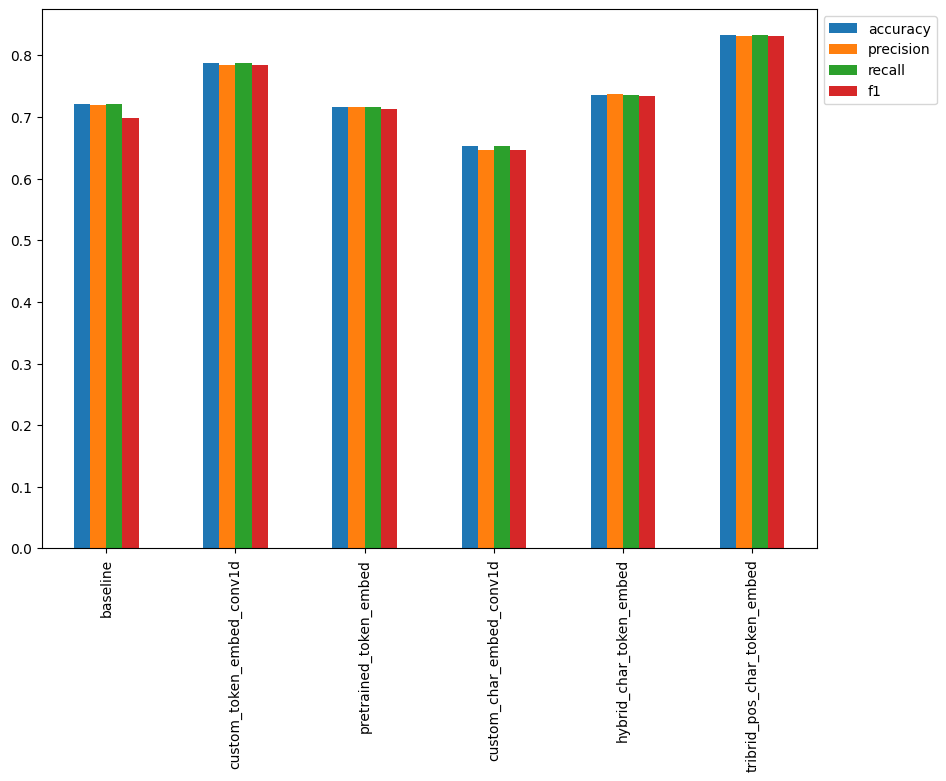

In [ ]:
# Plot and compare all of the model results
all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0));


Since the PubMed 200k RCT: a Dataset for Sequential Sentence Classification in Medical Abstracts paper compares their tested model's F1-scores on the test dataset, let's take at our model's F1-scores.



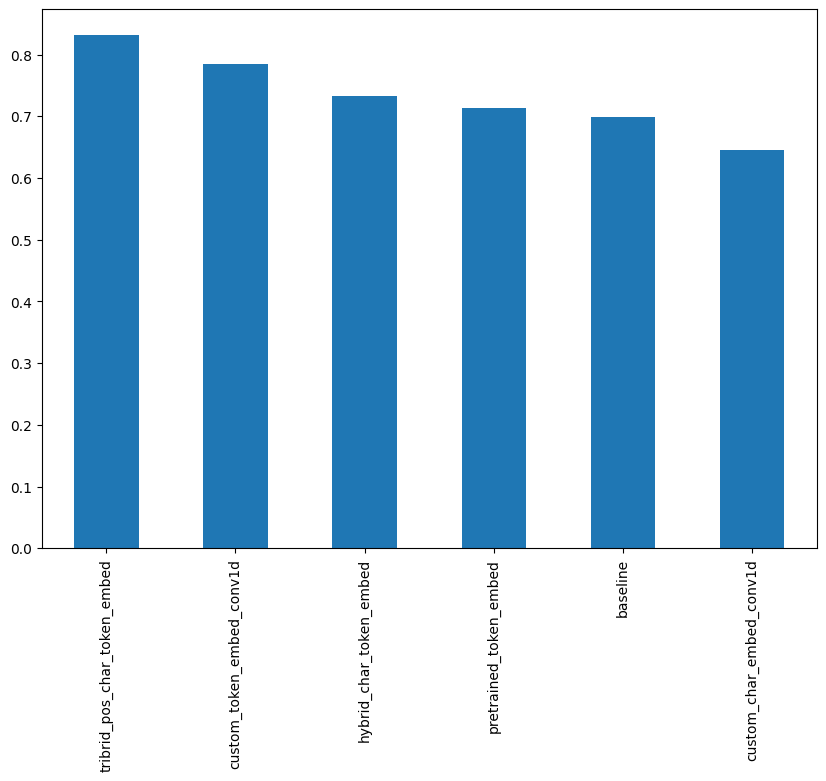

In [ ]:
# Sort model results by f1- score
all_model_results .sort_values("f1", ascending=False)["f1"].plot(kind="bar" , figsize=(10,7));

## saving and loading best performing model


In [ ]:
model_5.save("skimlit_tribid_model.keras") #model will be saved to path specified by string

In [ ]:
# Download pretrained model from Google Storage
!wget https://storage.googleapis.com/ztm_tf_course/skimlit/skimlit_tribrid_model.zip
!mkdir skimlit_gs_model
!unzip skimlit_tribrid_model.zip -d skimlit_gs_model

--2026-05-17 15:09:54--  https://storage.googleapis.com/ztm_tf_course/skimlit/skimlit_tribrid_model.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.118.207, 64.233.170.207, 74.125.200.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.118.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 962182847 (918M) [application/zip]
Saving to: ‘skimlit_tribrid_model.zip’

skimlit_tribrid_mod 100%[===================>] 917.61M  17.6MB/s    in 56s     

2026-05-17 15:10:50 (16.4 MB/s) - ‘skimlit_tribrid_model.zip’ saved [962182847/962182847]

Archive:  skimlit_tribrid_model.zip
   creating: skimlit_gs_model/skimlit_tribrid_model/
  inflating: skimlit_gs_model/skimlit_tribrid_model/keras_metadata.pb  
   creating: skimlit_gs_model/skimlit_tribrid_model/assets/
 extracting: skimlit_gs_model/skimlit_tribrid_model/fingerprint.pb  
   creating: skimlit_gs_model/skimlit_tribrid_model/variables/
  inflating: skimlit_gs_model/

In [ ]:
# Importing tensorflow model dependencies
import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from keras.layers import TFSMLayer


In [ ]:
model_path = "skimlit_gs_model/skimlit_tribrid_model"

# Wrap SavedModel as a layer
loaded_model = TFSMLayer(model_path, call_endpoint="serving_default")

### Make predictions and evaluate them against the truth labels

To make sure our model saved and loaded correctly,
Predict , evaluate them and then compare them to the prediction results we calculated earlier.

In [ ]:
# Evaluate loaded model's predictions
loaded_model_results = calculate_results(val_labels_encoded ,
                                         loaded_preds)
loaded_model_results

NameError: name 'loaded_preds' is not defined

In [ ]:
# Compare loaded model results with original trained model results
np.isclose(list(model_5_results.values()), list(loaded_model_results.values()) , rtol = 1e-02)

In [ ]:
#Check loaded model summary (note the number of trainable parameters)
loaded_model.summary()

### Evaluate model on test dataset

In [ ]:
#Create test dataset batch and prefetched
test_pos_char_token_data = tf.data.Dataset.from_tensor_slices((test_line_numbers_one_hot,
                                                               test_total_lines_one_hot,
                                                               test_sentences,
                                                               test_chars))
test_pos_char_token_labels = tf.data.Dataset.from_tensor_slices(test_labels_one_hot)
test_pos_char_token_dataset = tf.data.Dataset.zip((test_pos_char_token_data, test_pos_char_token_labels))
test_pos_char_token_dataset = test_pos_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Check shapes
test_pos_char_token_dataset


In [ ]:
# Make predictions on the test dataset
test_pred_probs = loaded_model.predict(test_pos_char_token_dataset,
                                       verbose =1)
test_preds = tf.argmax(test_pred_probs , axis =1)
test_preds[:10]

In [ ]:
# Evaluate loaded model test predictions
loaded_model_test_results = calculate_results(y_true = test_labels_encoded,
                                              y_pred = test_preds)
loaded_model_test_results